In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

# Bilkul official aur active URL se data load kar rahe hain (Semicolon separator ke sath)
url = "https://raw.githubusercontent.com/madmashup/targeted-marketing-predictive-engine/master/banking.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


--- Missing Values ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

--- Target Variable Distribution ---
y
0    36548
1     4640
Name: count, dtype: int64


/tmp/ipykernel_1019/342720727.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Set2')


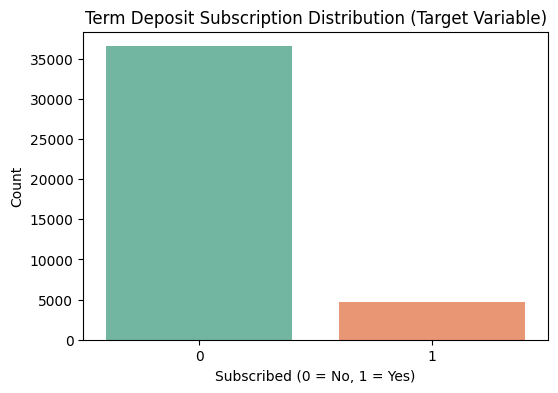

In [6]:
# 1. Missing values check karna
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Target variable ('y') ka distribution dekhna (0 = No, 1 = Yes)
print("\n--- Target Variable Distribution ---")
print(df['y'].value_counts())

# 3. Target variable ka countplot graph banana
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Term Deposit Subscription Distribution (Target Variable)')
plt.xlabel('Subscribed (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# 1. Data ko safe side dobara load kar rahe hain taake koi link break na ho
url = "https://raw.githubusercontent.com/madmashup/targeted-marketing-predictive-engine/master/banking.csv"
df_main = pd.read_csv(url)

# 2. Categorical features ko encode karna
df_encoded = df_main.copy()
le = LabelEncoder()
categorical_cols = df_encoded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# 3. Features aur Target ko define karna aur split karna
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Logistic Regression Model Train karna
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 5. Random Forest Model Train karna
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 6. Final Results Print karna
print("================ LOGISTIC REGRESSION REPORT ================")
print(classification_report(y_test, lr_preds))
print("Logistic Regression F1-Score:", round(f1_score(y_test, lr_preds), 4))

print("\n================ RANDOM FOREST REPORT ================")
print(classification_report(y_test, rf_preds))
print("Random Forest F1-Score:", round(f1_score(y_test, rf_preds), 4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


================ LOGISTIC REGRESSION REPORT ================
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7295
           1       0.64      0.42      0.51       943

    accuracy                           0.91      8238
   macro avg       0.79      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238

Logistic Regression F1-Score: 0.5055

================ RANDOM FOREST REPORT ================
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7295
           1       0.63      0.53      0.58       943

    accuracy                           0.91      8238
   macro avg       0.79      0.74      0.76      8238
weighted avg       0.90      0.91      0.91      8238

Random Forest F1-Score: 0.5754


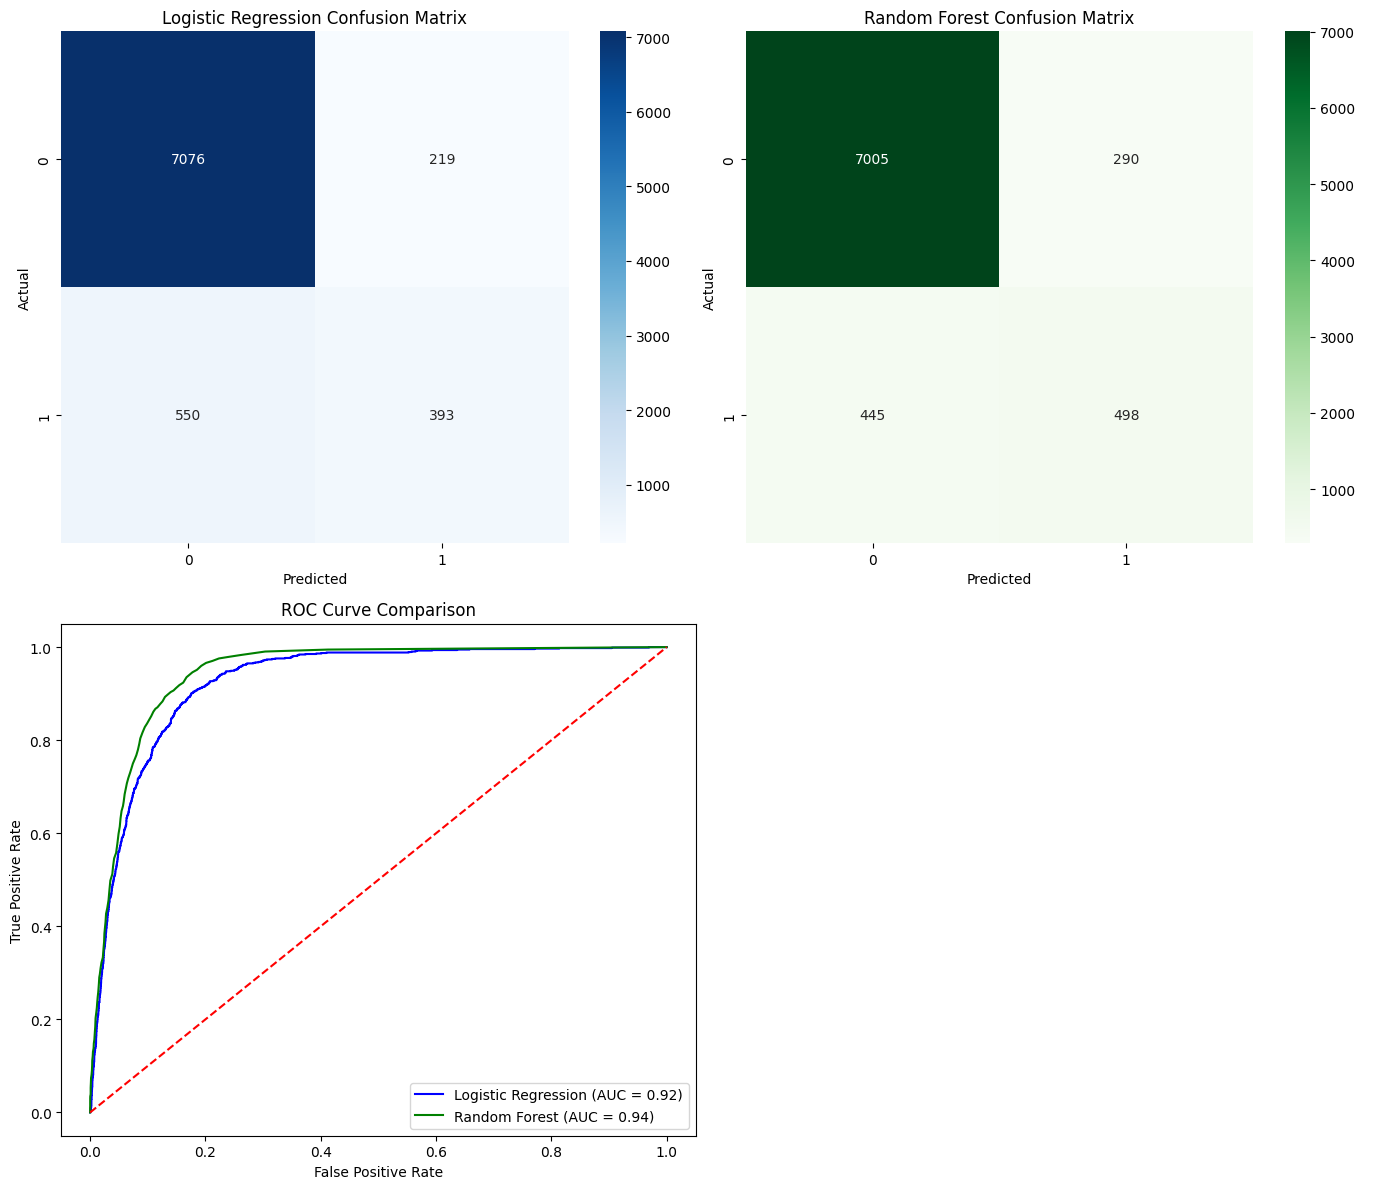

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Plots ka setup (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('Logistic Regression Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# 2. Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[0,1], cmap='Greens')
axes[0,1].set_title('Random Forest Confusion Matrix')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# 3. ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1,0].plot(fpr_lr, tpr_lr, color='blue', label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
axes[1,0].plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
axes[1,0].plot([0, 1], [0, 1], color='red', linestyle='--')
axes[1,0].set_title('ROC Curve Comparison')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend(loc='lower right')

# Chothay subplot ko hide kar rahe hain
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

Generating SHAP Bar Plot...


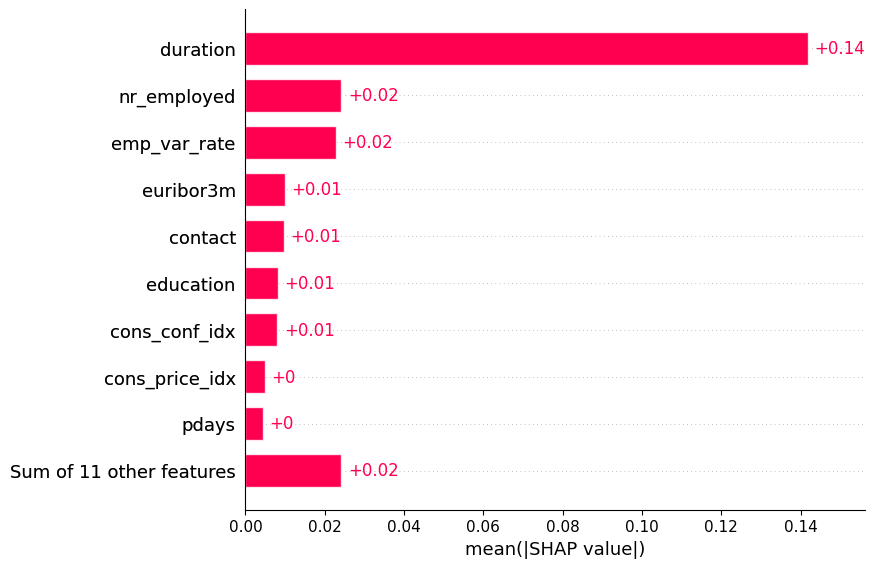


Detailed breakdown for the first customer prediction:


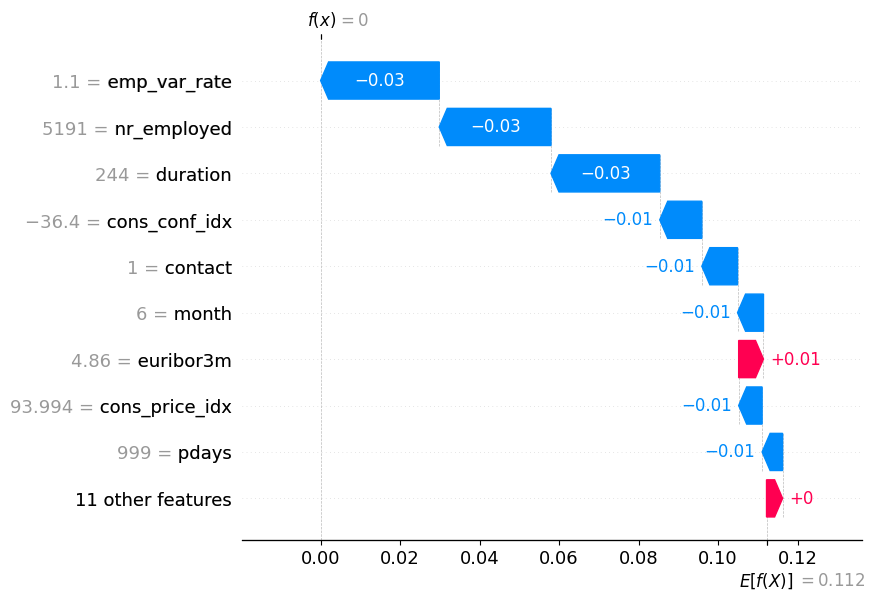

In [12]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)

X_sample = X_test.iloc[:5]
shap_values_sample = explainer(X_sample)
if isinstance(shap_values_sample, list):

    shap_obj = shap_values_sample[1]
elif len(shap_values_sample.shape) == 3:
    shap_obj = shap_values_sample[:, :, 1]
else:
    shap_obj = shap_values_sample

print("Generating SHAP Bar Plot...")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_obj, max_display=10)
plt.show()

print("\nDetailed breakdown for the first customer prediction:")
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_obj[0], max_display=10)
plt.show()

================ TASK 2: DATASET LOADED ================
Dataset Shape: (200, 5)

Pehle 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

🎯 Generating Customer Segmentation Graph using PCA...


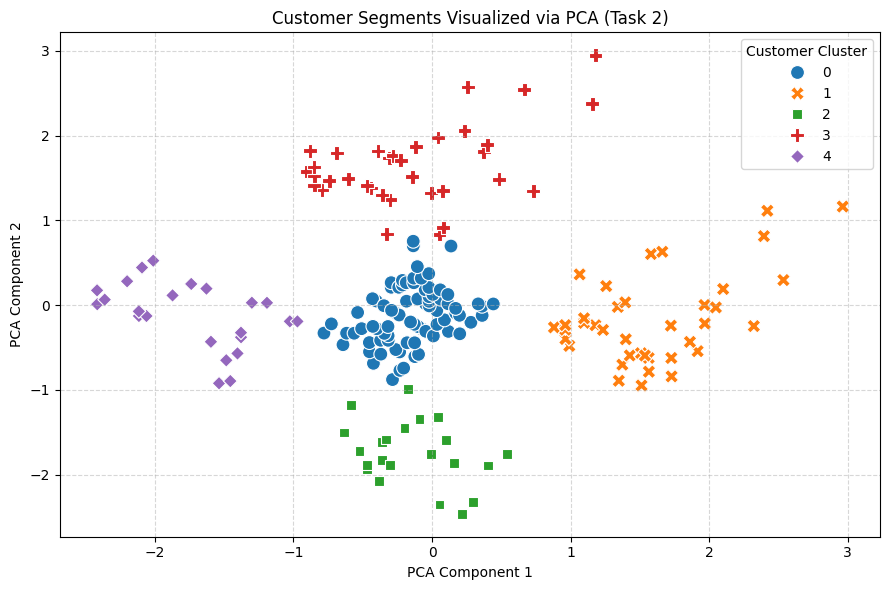


📋 Each Cluster Characteristics (Mean Values):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Mall Customers Dataset ko online repository se direct load karna
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df_mall = pd.read_csv(url)

print("================ TASK 2: DATASET LOADED ================")
print("Dataset Shape:", df_mall.shape)
print("\nPehle 5 rows:")
print(df_mall.head())

# 2. Relevant Features select karna (Annual Income aur Spending Score)
X_features = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Features ko Scale (Normalize) karna taake clustering accurate ho
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 4. K-Means Clustering Model Train karna (Standard 5 clusters segmentation ke liye)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_mall['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Dimensionality Reduction (PCA) lagana visualization ke liye
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_mall['PCA1'] = X_pca[:, 0]
df_mall['PCA2'] = X_pca[:, 1]

# 6. Final Clusters ka VIP Scatter Plot graph banana
print("\n🎯 Generating Customer Segmentation Graph using PCA...")
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_mall, palette='tab10', s=100, style='Cluster')
plt.title('Customer Segments Visualized via PCA (Task 2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Customer Cluster')
plt.tight_layout()
plt.show()

# 7. Har cluster ki marketing profiles print karna (Mean Values)
print("\n📋 Each Cluster Characteristics (Mean Values):")
print(df_mall.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

url = "https://raw.githubusercontent.com/tanishq-b-02/Loan-Prediction-Dataset/main/train.csv"
df_loan = pd.read_csv(url)

print("================ TASK 4: DATASET LOADED ================")
print("Dataset Shape:", df_loan.shape)

for col in df_loan.columns:
    if df_loan[col].dtype == 'object':
        df_loan[col].fillna(df_loan[col].mode()[0], inplace=True)
    else:
        df_loan[col].fillna(df_loan[col].median(), inplace=True)

le = LabelEncoder()
for col in df_loan.select_dtypes(include=['object']).columns:
    if col != 'Loan_ID':
        df_loan[col] = le.fit_transform(df_loan[col])

X_loan = df_loan.drop(columns=['Loan_ID', 'Loan_Status'])
y_loan = df_loan['Loan_Status']
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_loan, y_loan, test_size=0.2, random_state=42)

loan_model = RandomForestClassifier(n_estimators=100, random_state=42)
loan_model.fit(X_train_l, y_train_l)
y_probs_l = loan_model.predict_proba(X_test_l)[:, 1]

cost_fn, cost_fp = 500, 100
thresholds = np.linspace(0, 1, 100)
total_costs = []

for t in thresholds:
    preds = (y_probs_l >= t).astype(int)
    cm = confusion_matrix(y_test_l, preds)
    fp = cm[0, 1] if cm.shape == (2,2) else 0
    fn = cm[1, 0] if cm.shape == (2,2) else 0
    total_costs.append((fp * cost_fp) + (fn * cost_fn))

optimal_threshold = thresholds[np.argmin(total_costs)]
min_cost = min(total_costs)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, total_costs, color='crimson', linewidth=2, label='Total Business Cost')
plt.axvline(optimal_threshold, color='darkblue', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.title('Business Cost Optimization via Threshold Tuning (Task 4)')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Financial Loss ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f" Optimal Decision Threshold: {optimal_threshold:.2f}")
print(f" Minimum Business Cost achieved: ${min_cost}")

HTTPError: HTTP Error 404: Not Found